# Wine clustering

Unsupervised sanity check: do KMeans clusters recover the three wine cultivars?

In [1]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = "png"
plt.rcParams["figure.dpi"] = 72
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from ml_toolkit.data import load_dataset
from ml_toolkit.features import make_preprocessor

In [2]:
X, y, names = load_dataset("wine")
Xs = make_preprocessor().fit_transform(X)
print(Xs.shape)

(178, 13)


## Choosing k by silhouette

In [3]:
sil = {}
for k in range(2, 7):
    labels = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(Xs)
    sil[k] = round(silhouette_score(Xs, labels), 4)
pd.Series(sil, name="silhouette")

2    0.2683
3    0.2849
4    0.2457
5    0.2026
6    0.1960
Name: silhouette, dtype: float64

In [4]:
km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(Xs)
print("ARI vs cultivar labels:", round(adjusted_rand_score(y, km.labels_), 4))

ARI vs cultivar labels: 0.8975


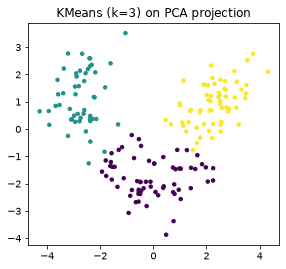

In [5]:
pcs = PCA(n_components=2, random_state=0).fit_transform(Xs)
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.scatter(pcs[:, 0], pcs[:, 1], c=km.labels_, s=12, cmap="viridis")
ax.set_title("KMeans (k=3) on PCA projection")
plt.show()

Clusters align well with the true cultivars; standardisation is essential here because feature scales differ by orders of magnitude (e.g. proline vs hue).